In [23]:
import numpy as np
import pandas as pd

import importlib
import funcs

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from funcs import inspect_sensors



importlib.reload(funcs)

from funcs import build_latest_sensor_statuses

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\cleaned_stats.csv")

In [3]:
sensor_id_col = "sensor_id"

conductivity_col = "conductivity_of_solution_ mS_cm"
orp_col = "oxidation_reduction_potential_ mV"
oxygen_col = "oxygen_saturation_%"
turbidity_col = "turbidity_NTU"

features = [
    conductivity_col,
    orp_col,
    oxygen_col,
    turbidity_col
]

N_CLUSTERS = 3
RANDOM_STATE = 42

# Weights used when K-means creates the clusters.
clustering_weights = {
    conductivity_col: 1.0,
    orp_col: 2.0,
    oxygen_col: 0.8,
    turbidity_col: 2.0
}

# Weights used later when interpreting and labelling the clusters.
# These do not have to remain identical to the clustering weights.
label_weights = {
    "conductivity_deviation": 1.0,
    "orp": 2.0,
    "oxygen": 0.8,
    "turbidity": 2.0
}

In [4]:
required_columns = [sensor_id_col] + features

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"The following required columns are missing: {missing_columns}"
    )

missing_value_counts = df[required_columns].isna().sum()
missing_value_counts = missing_value_counts[
    missing_value_counts > 0
]

if not missing_value_counts.empty:
    print("Missing values found:")
    display(missing_value_counts)

    raise ValueError(
        "K-means cannot run with missing values. "
        "Handle these values before continuing."
    )

# Work on a copy so the original dataframe remains unchanged.
work_df = df.copy().reset_index(drop=True)

# Preserve the row position for later alignment and sorting.
work_df["_row_id"] = np.arange(len(work_df))

print("Rows:", len(work_df))
print("Sensors:", work_df[sensor_id_col].nunique())

Rows: 13822
Sensors: 9


In [5]:
cluster_scaler = RobustScaler()

scaled_values = cluster_scaler.fit_transform(
    work_df[features]
)

df_scaled = pd.DataFrame(
    scaled_values,
    columns=features,
    index=work_df.index
)

# Apply the clustering weights after scaling.
for feature, weight in clustering_weights.items():
    df_scaled[feature] = df_scaled[feature] * weight

display(df_scaled.head())

,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
0,0.121441,-2.338025,0.796232,-0.798672
1,-0.051781,-2.298553,0.901450,-0.602295
2,0.076962,-1.454690,1.171294,-1.259596
3,0.506165,0.705189,0.849136,1.885114
4,0.986641,-0.518747,-0.278415,-0.782857


In [6]:
processed_sensor_dfs = []
skipped_sensors = []

sensor_groups = work_df.groupby(
    sensor_id_col,
    sort=False
).groups

for sensor, sensor_indices in sensor_groups.items():

    sensor_indices = pd.Index(sensor_indices)

    sensor_data = df_scaled.loc[
        sensor_indices,
        features
    ]

    original_sensor_data = work_df.loc[
        sensor_indices
    ].copy()

    # K-means needs at least three observations.
    if len(sensor_data) < N_CLUSTERS:
        skipped_sensors.append(
            {
                "sensor_id": sensor,
                "reason": "Fewer than 3 observations"
            }
        )
        continue

    # It also needs at least three distinct points.
    if sensor_data.drop_duplicates().shape[0] < N_CLUSTERS:
        skipped_sensors.append(
            {
                "sensor_id": sensor,
                "reason": "Fewer than 3 distinct feature combinations"
            }
        )
        continue

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=20
    )

    original_sensor_data["cluster"] = (
        kmeans.fit_predict(sensor_data)
    )

    processed_sensor_dfs.append(original_sensor_data)

if not processed_sensor_dfs:
    raise ValueError(
        "No sensors contained enough data to create three clusters."
    )

clustered_df = pd.concat(
    processed_sensor_dfs,
    axis=0
).sort_values("_row_id")

print("Clustered rows:", len(clustered_df))
print("Clustered sensors:", clustered_df[sensor_id_col].nunique())

if skipped_sensors:
    print("\nSkipped sensors:")
    display(pd.DataFrame(skipped_sensors))

Clustered rows: 13822
Clustered sensors: 9


c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [7]:
label_scaler = RobustScaler()

label_scale_features = [
    turbidity_col,
    orp_col,
    oxygen_col
]

scaled_label_values = label_scaler.fit_transform(
    work_df[label_scale_features]
)

label_scaled_df = pd.DataFrame(
    scaled_label_values,
    columns=[
        "scaled_turbidity",
        "scaled_orp",
        "scaled_oxygen"
    ],
    index=work_df.index
)

display(label_scaled_df.head())

,scaled_turbidity,scaled_orp,scaled_oxygen
0,-0.399336,-1.169013,0.995290
1,-0.301148,-1.149276,1.126813
2,-0.629798,-0.727345,1.464117
3,0.942557,0.352595,1.061421
4,-0.391429,-0.259374,-0.348019


In [8]:
conductivity_group = work_df.groupby(
    sensor_id_col
)[conductivity_col]

conductivity_median = conductivity_group.transform(
    "median"
)

conductivity_q1 = conductivity_group.transform(
    lambda values: values.quantile(0.25)
)

conductivity_q3 = conductivity_group.transform(
    lambda values: values.quantile(0.75)
)

conductivity_iqr = (
    conductivity_q3 - conductivity_q1
).replace(0, np.nan)

conductivity_deviation = (
    (
        work_df[conductivity_col] - conductivity_median
    ).abs()
    / conductivity_iqr
)

conductivity_deviation = (
    conductivity_deviation
    .fillna(0)
    .clip(lower=0, upper=5)
)

label_scaled_df["conductivity_deviation"] = (
    conductivity_deviation
)

display(label_scaled_df.head())

,scaled_turbidity,scaled_orp,scaled_oxygen,conductivity_deviation
0,-0.399336,-1.169013,0.995290,0.307408
1,-0.301148,-1.149276,1.126813,0.360681
2,-0.629798,-0.727345,1.464117,0.039454
3,0.942557,0.352595,1.061421,0.736817
4,-0.391429,-0.259374,-0.348019,0.153674


In [9]:
label_scaled_df["measurement_quality_score"] = (
      label_weights["turbidity"]
      * label_scaled_df["scaled_turbidity"]

    - label_weights["orp"]
      * label_scaled_df["scaled_orp"]

    - label_weights["oxygen"]
      * label_scaled_df["scaled_oxygen"]

    + label_weights["conductivity_deviation"]
      * label_scaled_df["conductivity_deviation"]
)

display(
    label_scaled_df[
        [
            "scaled_turbidity",
            "scaled_orp",
            "scaled_oxygen",
            "conductivity_deviation",
            "measurement_quality_score"
        ]
    ].describe()
)

,scaled_turbidity,scaled_orp,scaled_oxygen,conductivity_deviation,measurement_quality_score
count,13822.000000,13822.000000,13822.000000,13822.000000,13822.000000
mean,0.150018,-0.088345,0.127468,0.640160,1.014911
std,0.688477,0.573333,0.709218,0.671139,2.110884
min,-0.709255,-1.576012,-2.382562,0.000000,-3.013664
25%,-0.403693,-0.554703,-0.390043,0.150931,-0.774945
50%,0.000000,0.000000,0.000000,0.432999,0.662191
75%,0.596307,0.445297,0.609957,0.859476,2.505580
max,2.742074,0.664887,3.070841,3.845049,8.751562


In [10]:
clustered_df["measurement_quality_score"] = (
    label_scaled_df.loc[
        clustered_df.index,
        "measurement_quality_score"
    ].to_numpy()
)

In [11]:
cluster_quality = (
    clustered_df
    .groupby(
        [sensor_id_col, "cluster"],
        as_index=False
    )
    .agg(
        cluster_quality_score=(
            "measurement_quality_score",
            "median"
        ),
        mean_quality_score=(
            "measurement_quality_score",
            "mean"
        ),
        median_turbidity=(
            turbidity_col,
            "median"
        ),
        median_orp=(
            orp_col,
            "median"
        ),
        median_oxygen=(
            oxygen_col,
            "median"
        ),
        median_conductivity=(
            conductivity_col,
            "median"
        ),
        observations=(
            "cluster",
            "size"
        )
    )
)

cluster_quality = cluster_quality.sort_values(
    "cluster_quality_score"
).reset_index(drop=True)

display(cluster_quality)

,sensor_id,cluster,cluster_quality_score,mean_quality_score,median_turbidity,median_orp,median_oxygen,median_conductivity,observations
0,981,2,-1.914129,-1.822909,1.945,325.645,59.555,61808.070,148
1,981,0,-1.681783,-1.688830,18.190,320.420,54.310,58231.460,145
2,983,2,-1.452957,-1.438311,20.980,296.210,99.090,29764.820,259
3,984,0,-1.306182,-1.084473,48.650,292.900,71.305,53088.895,546
4,982,1,-1.212325,-1.090935,96.455,334.120,59.980,32639.625,1502
5,982,2,-0.778498,-0.460991,3.360,292.060,63.210,41856.700,399
6,981,1,-0.670362,-0.659826,20.120,343.290,39.820,46905.250,124
7,984,1,-0.558975,-0.330110,158.915,295.285,69.305,53447.965,1330
8,978,0,-0.538549,-0.418744,8.740,5.120,90.905,56746.360,656
9,979,2,0.095584,0.367577,138.535,207.770,65.860,58502.550,792


In [12]:
ok_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(1 / 3)

danger_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(2 / 3)

print(f"Ok cutoff:     {ok_cutoff:.4f}")
print(f"Danger cutoff: {danger_cutoff:.4f}")

Ok cutoff:     -0.1158
Danger cutoff: 2.4137


In [13]:
cluster_quality["Water_Quality_Label"] = np.select(
    [
        cluster_quality["cluster_quality_score"] <= ok_cutoff,
        cluster_quality["cluster_quality_score"] < danger_cutoff
    ],
    [
        "Ok",
        "Medium"
    ],
    default="Danger"
)

display(
    cluster_quality[
        [
            sensor_id_col,
            "cluster",
            "cluster_quality_score",
            "median_turbidity",
            "median_orp",
            "median_oxygen",
            "median_conductivity",
            "Water_Quality_Label"
        ]
    ].sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)

,sensor_id,cluster,cluster_quality_score,median_turbidity,median_orp,median_oxygen,median_conductivity,Water_Quality_Label
13,976,0,0.557539,35.830,-139.825,93.345,56891.520,Medium
15,976,2,1.760990,134.140,-106.480,88.100,57021.090,Medium
18,976,1,2.496654,208.160,-118.230,85.785,56864.960,Danger
24,977,0,4.225923,317.005,-171.805,46.635,59462.390,Danger
25,977,2,5.627659,495.810,-153.340,65.890,49776.060,Danger
26,977,1,7.000557,716.615,-152.095,57.410,58756.925,Danger
8,978,0,-0.538549,8.740,5.120,90.905,56746.360,Ok
17,978,2,2.372286,357.260,6.430,87.230,55878.830,Medium
22,978,1,3.695038,568.030,68.660,86.750,56016.860,Danger
9,979,2,0.095584,138.535,207.770,65.860,58502.550,Medium


In [14]:
cluster_label_information = cluster_quality[
    [
        sensor_id_col,
        "cluster",
        "cluster_quality_score",
        "Water_Quality_Label"
    ]
]

final_training_df = clustered_df.merge(
    cluster_label_information,
    on=[sensor_id_col, "cluster"],
    how="left",
    validate="many_to_one"
)

final_training_df = (
    final_training_df
    .sort_values("_row_id")
    .reset_index(drop=True)
)

display(final_training_df.head())

,Unnamed: 0,id,date_insert,sensor_id,wtempV_°C,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,total_suspended_solids_mg_L,turbidity_NTU,dissolved_oxygen_concentration _ppm,dissolved_oxygen_concentration_mg_L,oxygen_saturation_%,salinity_ppt,dissolved_solids _ppm,location,_row_id,cluster,measurement_quality_score,cluster_quality_score,Water_Quality_Label
0,2,3.0,2025-07-03 15:00:00,976,24.96,56828.55,-170.59,63.73,80.74,7.91,7.91,95.62,37.99,37057.90,Ακταίο,0,0,1.050530,0.557539,Medium
1,3,4.0,2025-07-03 15:00:00,977,25.18,55496.83,-164.88,171.17,106.32,8.16,8.16,99.18,36.93,36189.48,Ψαθόπυργος,1,0,1.155488,4.225923,Danger
2,4,5.0,2025-07-03 15:00:00,978,23.61,56486.60,-42.81,37.69,20.70,9.18,9.18,108.31,37.72,36834.91,Αραχωβίτικα,2,0,-0.936746,-0.538549,Ok
3,5,6.0,2025-07-03 15:00:00,979,25.25,59786.27,269.63,742.15,430.33,8.01,8.01,97.41,40.39,38986.63,Άγιος Βασίλης,3,0,1.067606,2.955638,Danger
4,6,7.0,2025-07-03 15:00:00,980,23.61,63480.13,92.58,95.88,82.80,5.03,5.03,59.26,43.43,41395.39,Ρίο,4,1,0.167979,0.117949,Medium


In [15]:
label_order = ["Ok", "Medium", "Danger"]

print("--- Overall Label Distribution ---")

label_distribution = (
    final_training_df["Water_Quality_Label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
)

display(label_distribution)


print("\n--- Feature Averages by Quality Label ---")

feature_averages = (
    final_training_df
    .groupby("Water_Quality_Label")[features]
    .mean()
    .reindex(label_order)
)

display(feature_averages)

--- Overall Label Distribution ---


Water_Quality_Label
Ok        5109
Medium    5312
Danger    3401
Name: count, dtype: int64


--- Feature Averages by Quality Label ---


,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
Water_Quality_Label,,,,
Ok,45978.085935,268.606211,70.964664,90.296843
Medium,56075.298887,82.206327,75.795262,213.287952
Danger,55512.123819,45.449291,68.156851,441.001929


In [16]:
sensor_label_counts = pd.crosstab(
    final_training_df[sensor_id_col],
    final_training_df["Water_Quality_Label"]
)

sensor_label_counts = sensor_label_counts.reindex(
    columns=label_order,
    fill_value=0
)

display(sensor_label_counts)

Water_Quality_Label,Ok,Medium,Danger
sensor_id,,,
976,0,875,182
977,0,0,821
978,656,593,275
979,0,1628,895
980,0,484,693
981,417,0,0
982,1901,389,0
983,259,1025,535
984,1876,318,0


In [17]:
silhouette_results = []

for sensor, sensor_results in final_training_df.groupby(
    sensor_id_col,
    sort=False
):

    row_ids = sensor_results["_row_id"].astype(int)

    sensor_scaled_data = df_scaled.loc[
        row_ids,
        features
    ]

    sensor_clusters = sensor_results["cluster"]

    number_of_clusters = sensor_clusters.nunique()

    if (
        number_of_clusters < 2
        or len(sensor_scaled_data) <= number_of_clusters
    ):
        continue

    score = silhouette_score(
        sensor_scaled_data,
        sensor_clusters
    )

    silhouette_results.append(
        {
            "sensor": sensor,
            "observations": len(sensor_results),
            "silhouette": score
        }
    )

silhouette_df = (
    pd.DataFrame(silhouette_results)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(silhouette_df)

print(
    "Mean silhouette:",
    round(silhouette_df["silhouette"].mean(), 4)
)

,sensor,observations,silhouette
0,981,417,0.534845
1,978,1524,0.529331
2,982,2290,0.521952
3,983,1819,0.506038
4,980,1177,0.452160
5,976,1057,0.441301
6,984,2194,0.411481
7,979,2523,0.401111
8,977,821,0.386127


Mean silhouette: 0.4649


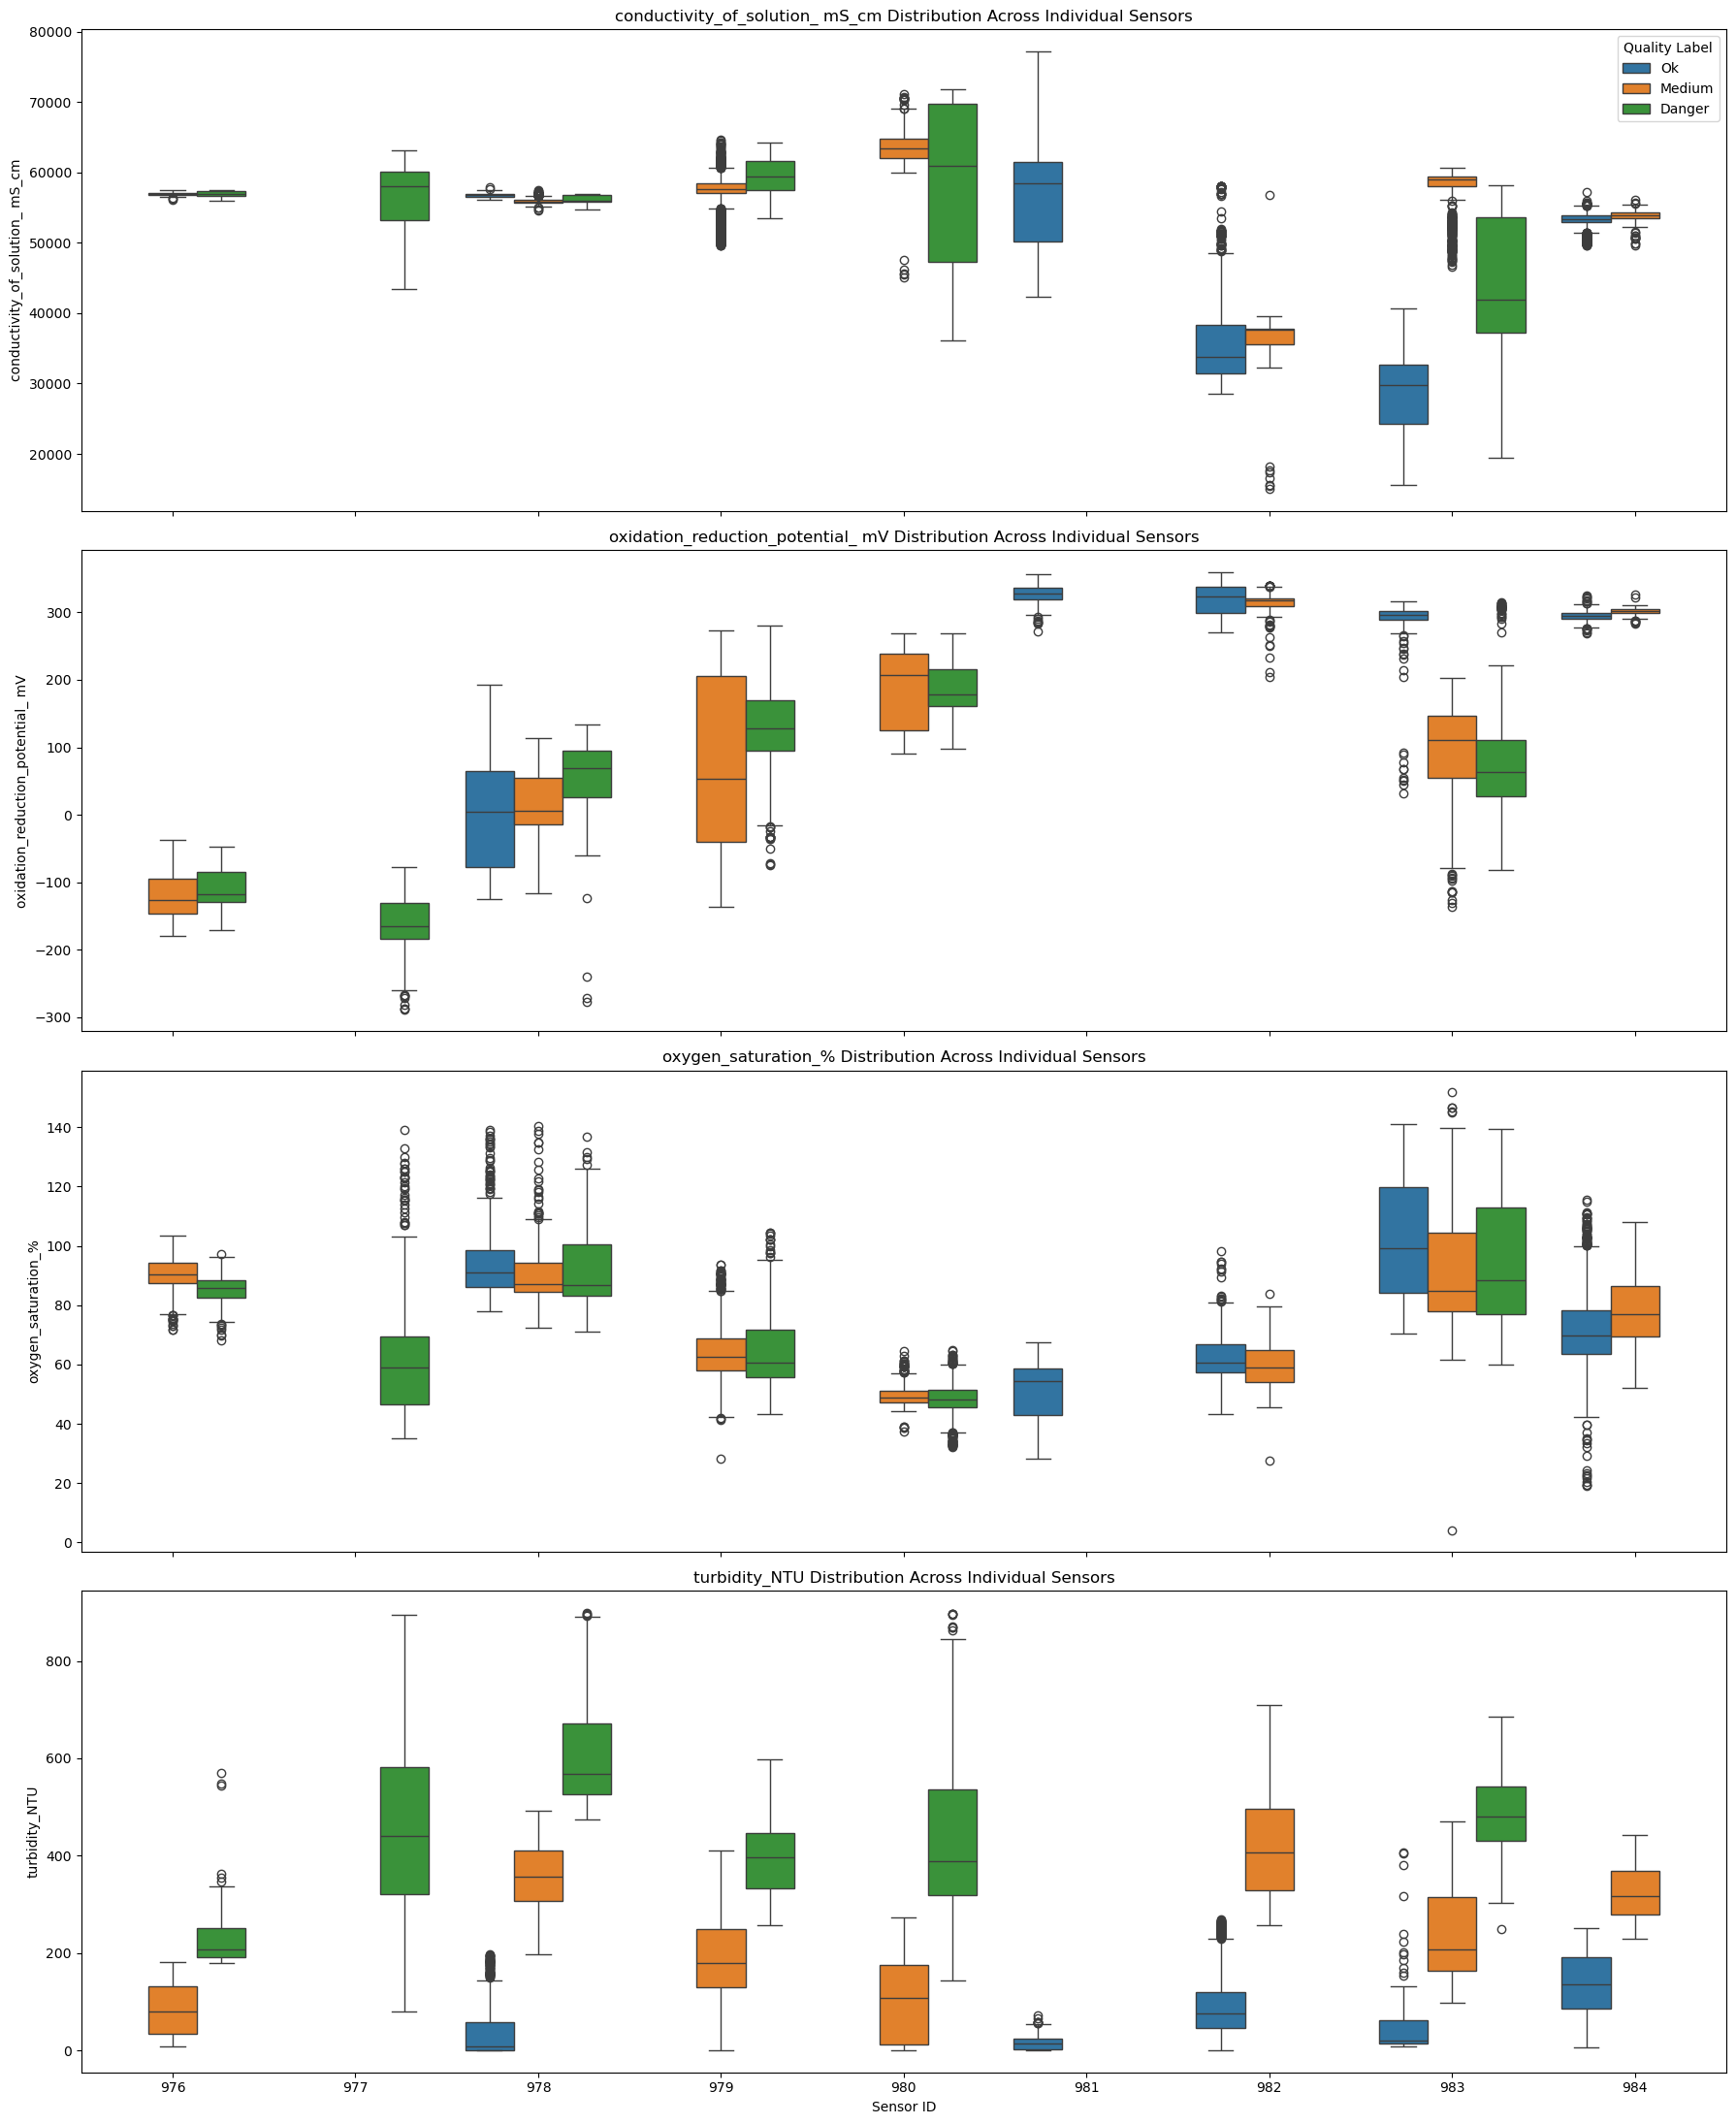

In [20]:
fig, axes = plt.subplots(
    nrows=len(features),
    ncols=1,
    figsize=(18, 22),
    sharex=True
)

for position, (axis, feature) in enumerate(
    zip(axes, features)
):

    sns.boxplot(
        data=final_training_df,
        x=sensor_id_col,
        y=feature,
        hue="Water_Quality_Label",
        hue_order=label_order,
        ax=axis
    )

    axis.set_title(
        f"{feature} Distribution Across Individual Sensors"
    )

    axis.set_ylabel(feature)

    if position < len(features) - 1:
        axis.set_xlabel("")

    # Keep only one legend.
    if position == 0:
        axis.legend(
            title="Quality Label",
            loc="upper right"
        )
    elif axis.get_legend() is not None:
        axis.get_legend().remove()

axes[-1].set_xlabel("Sensor ID")

plt.tight_layout()
plt.show()

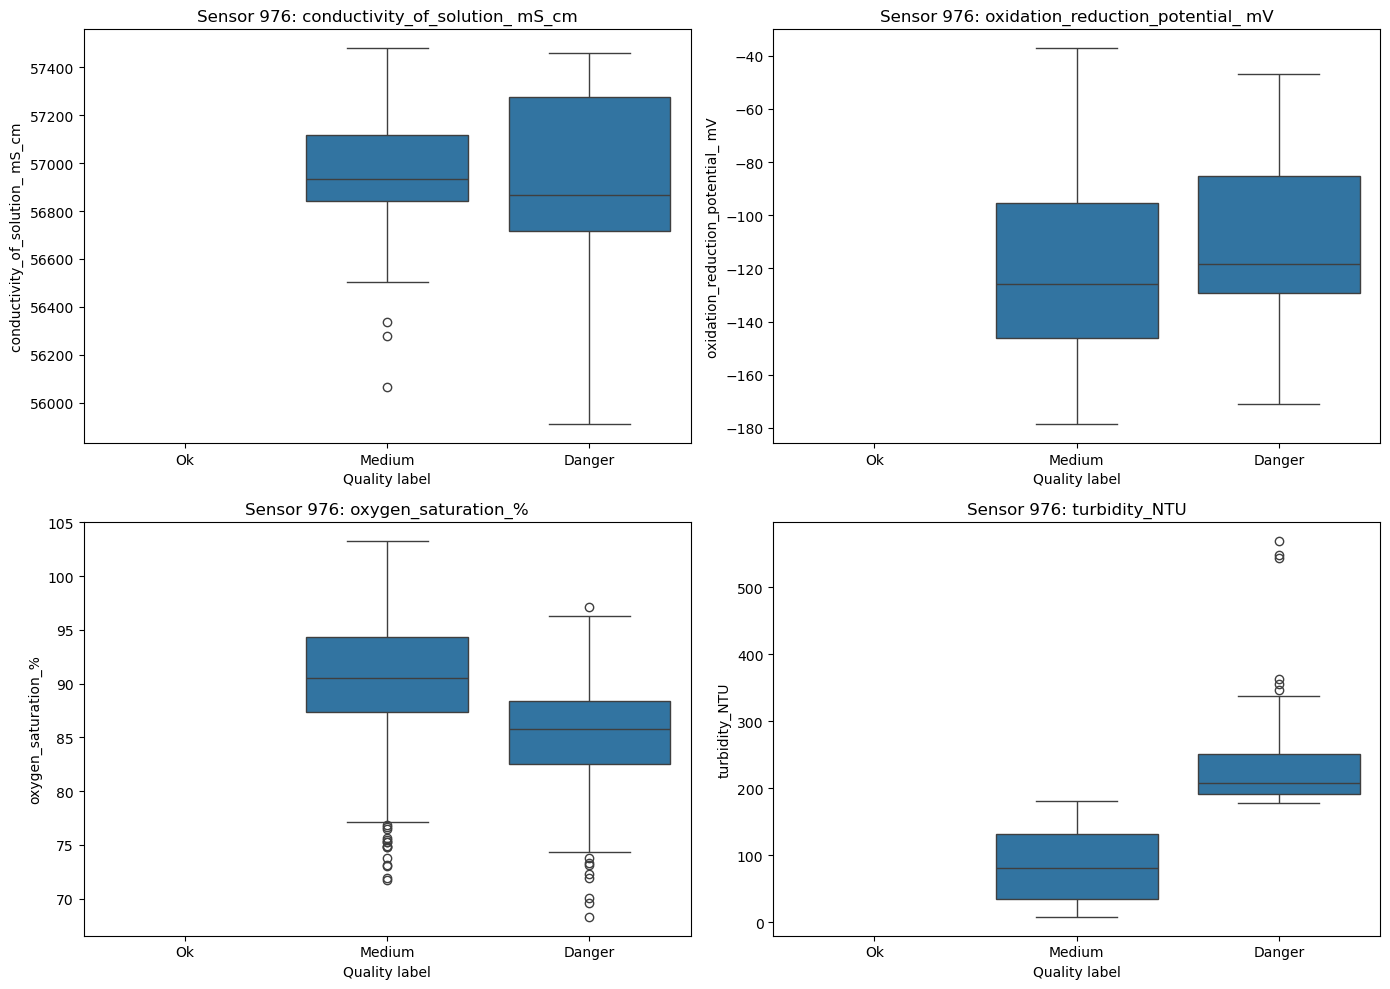

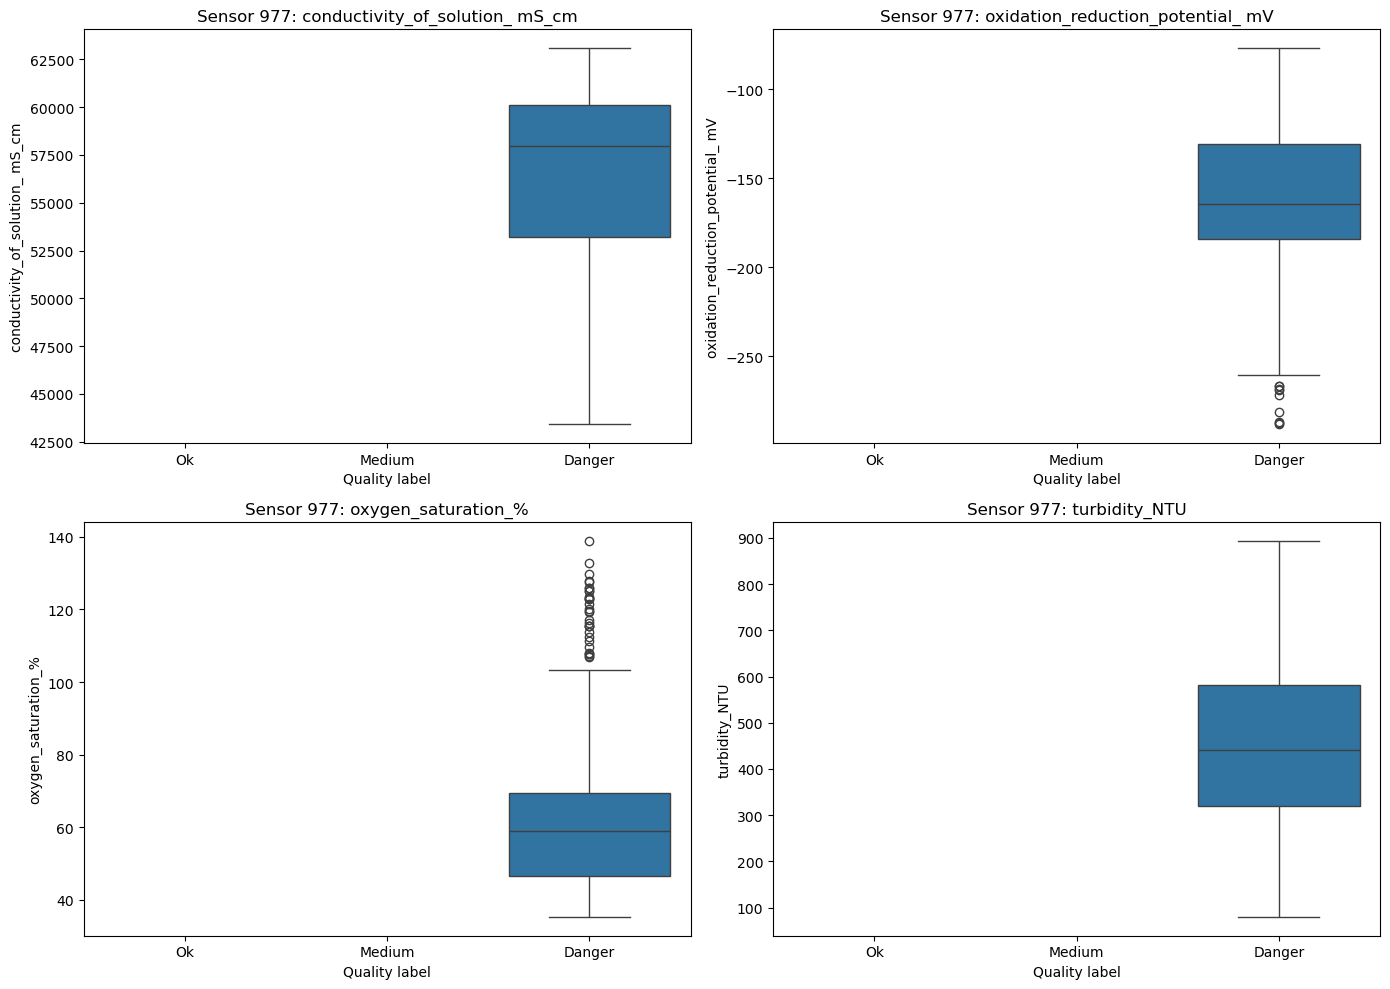

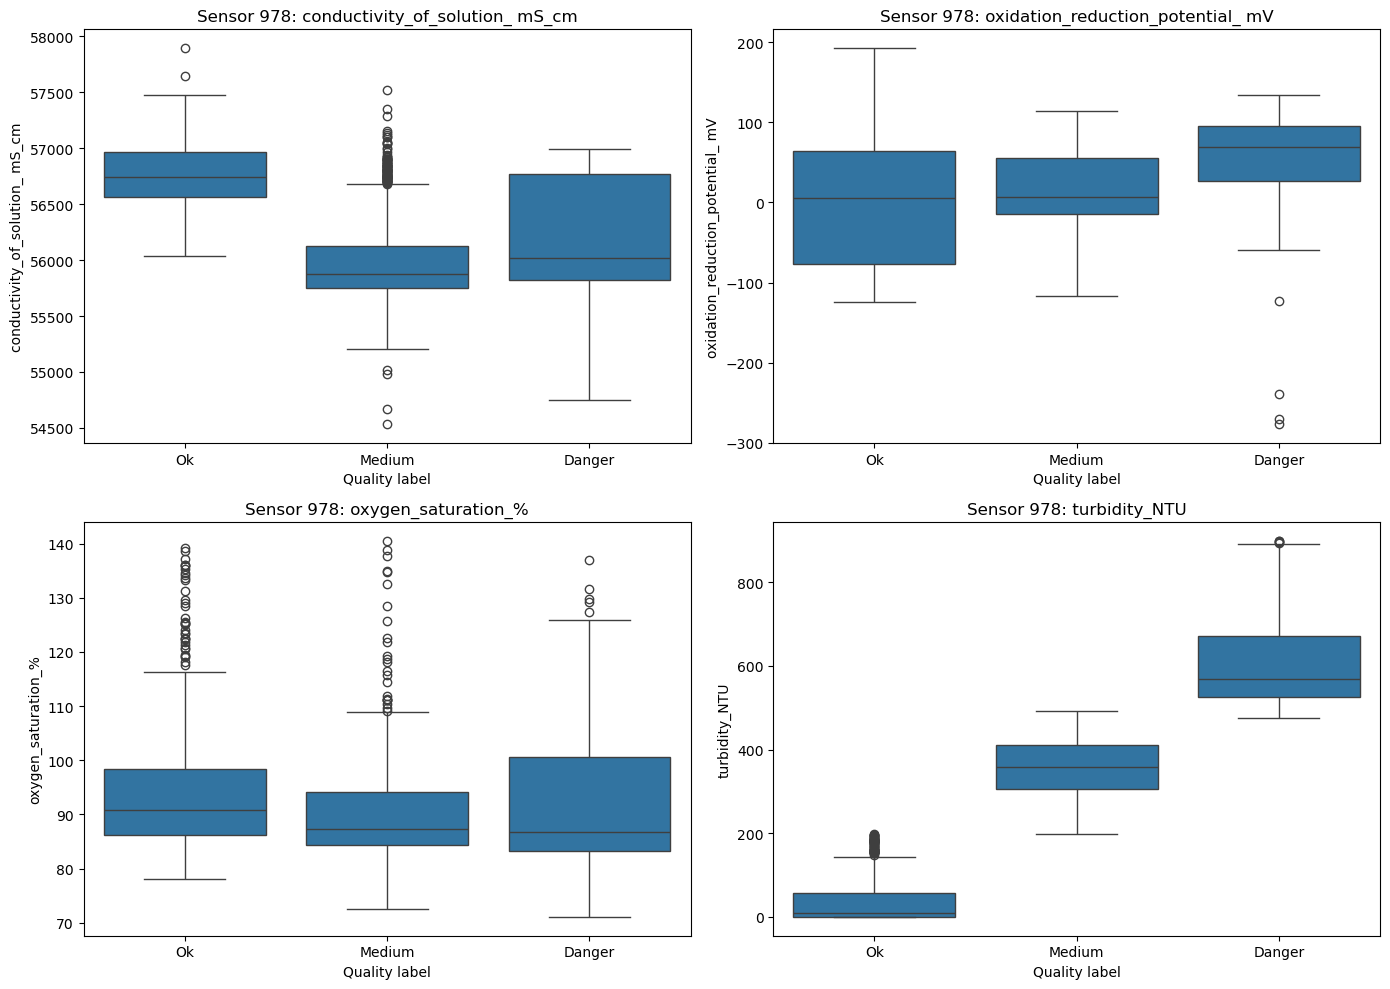

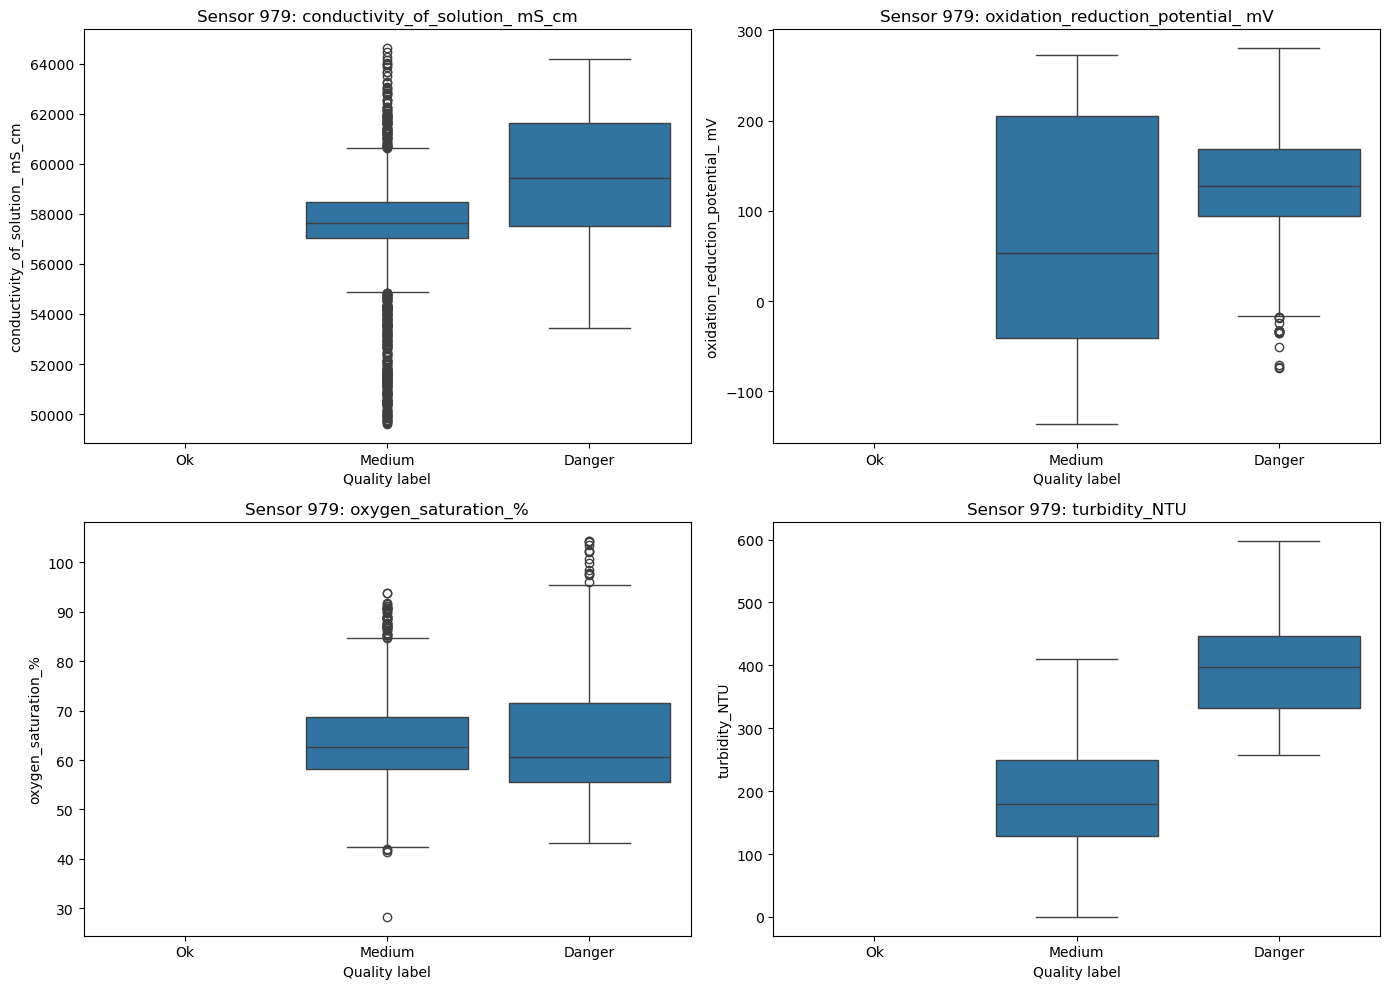

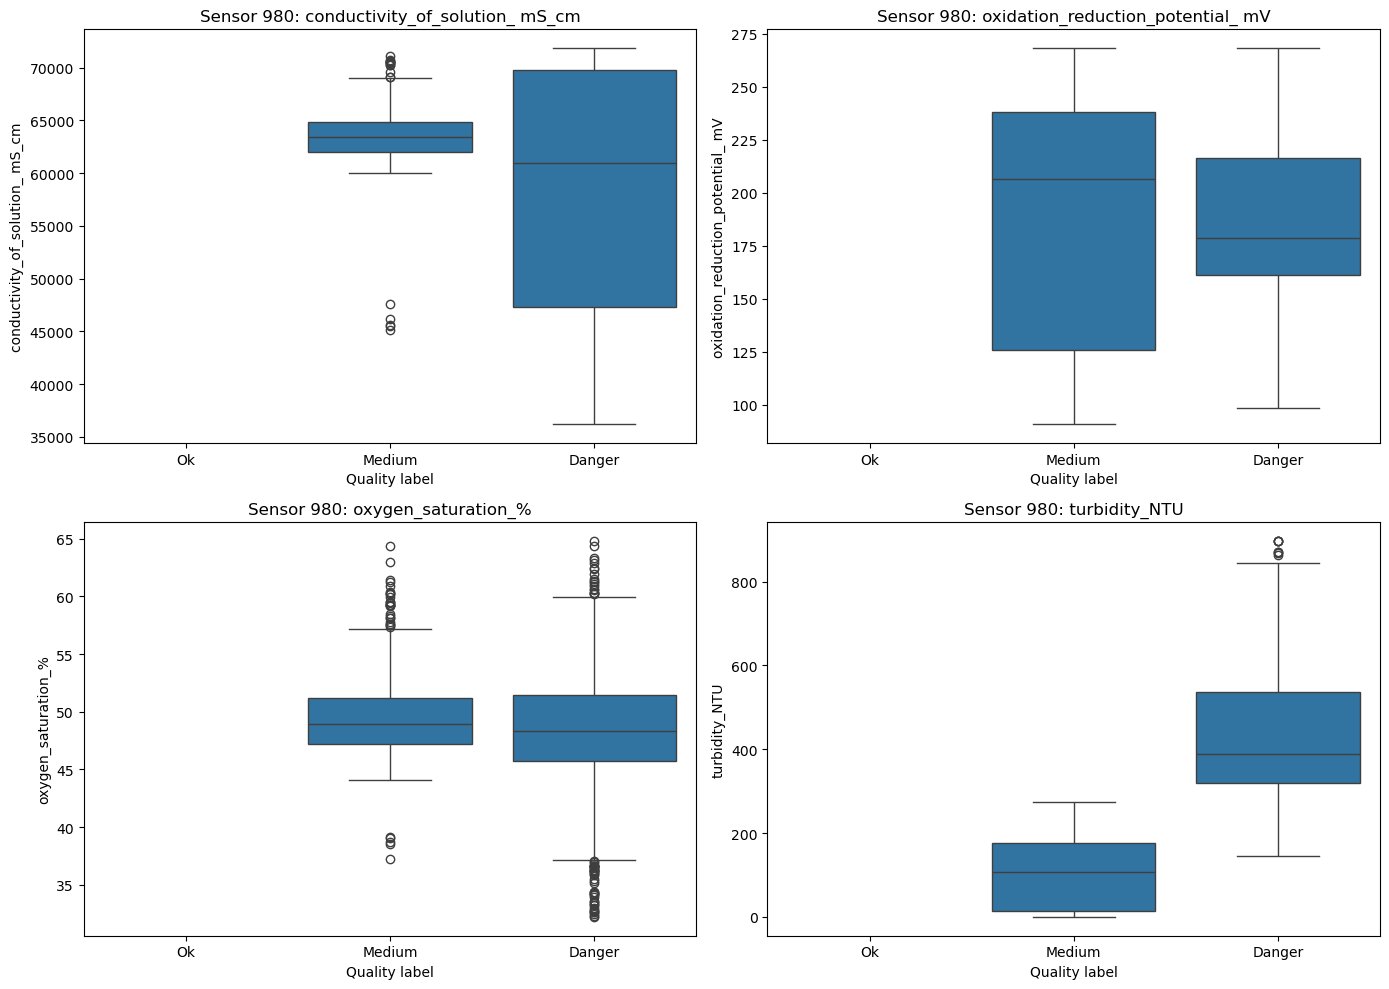

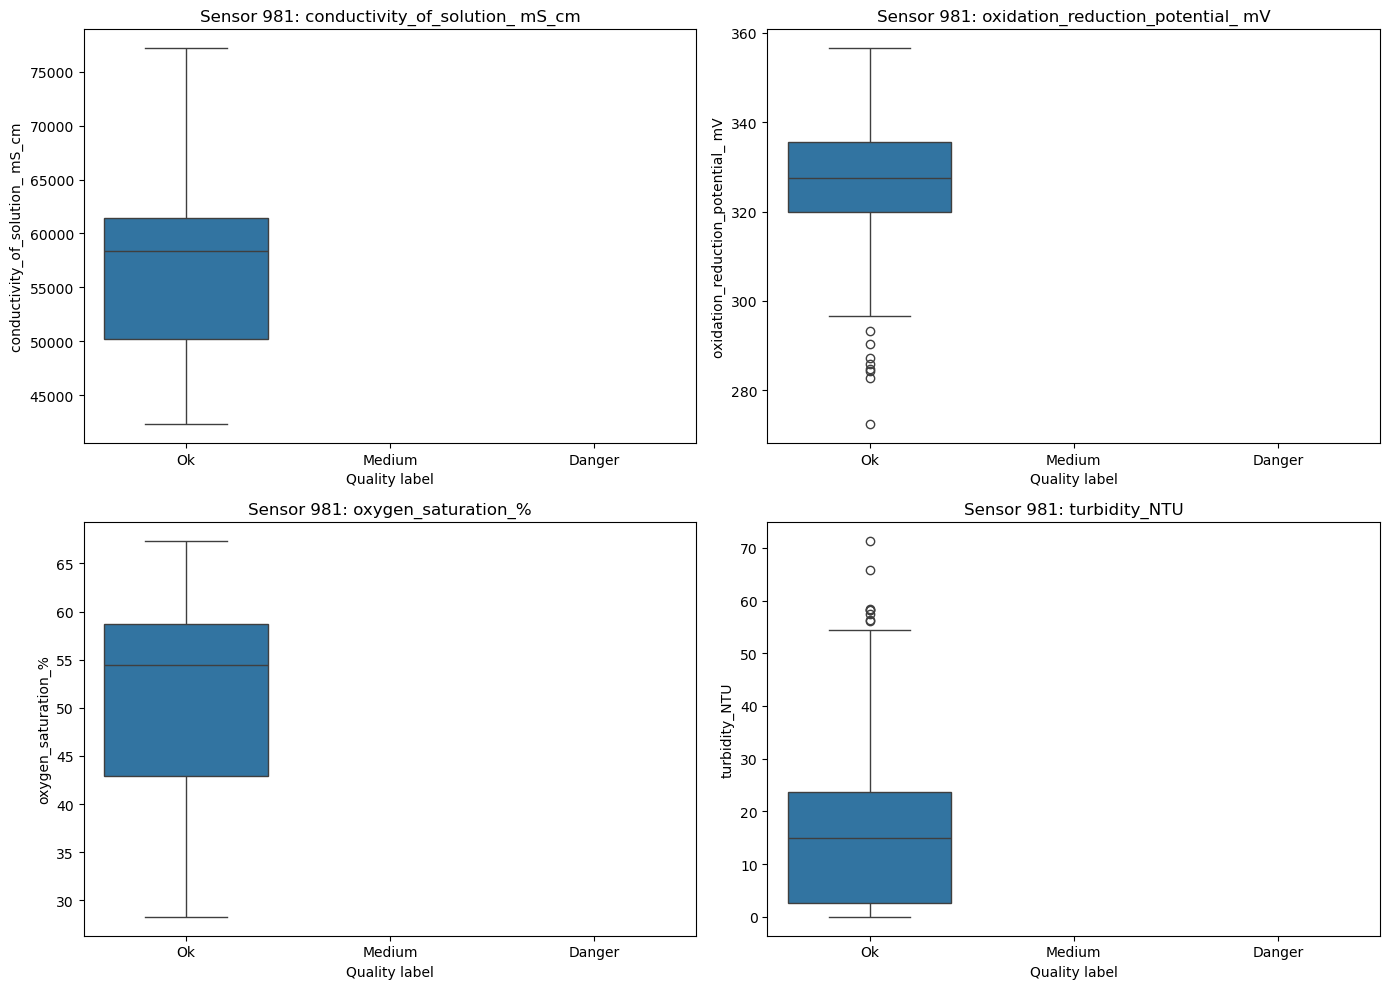

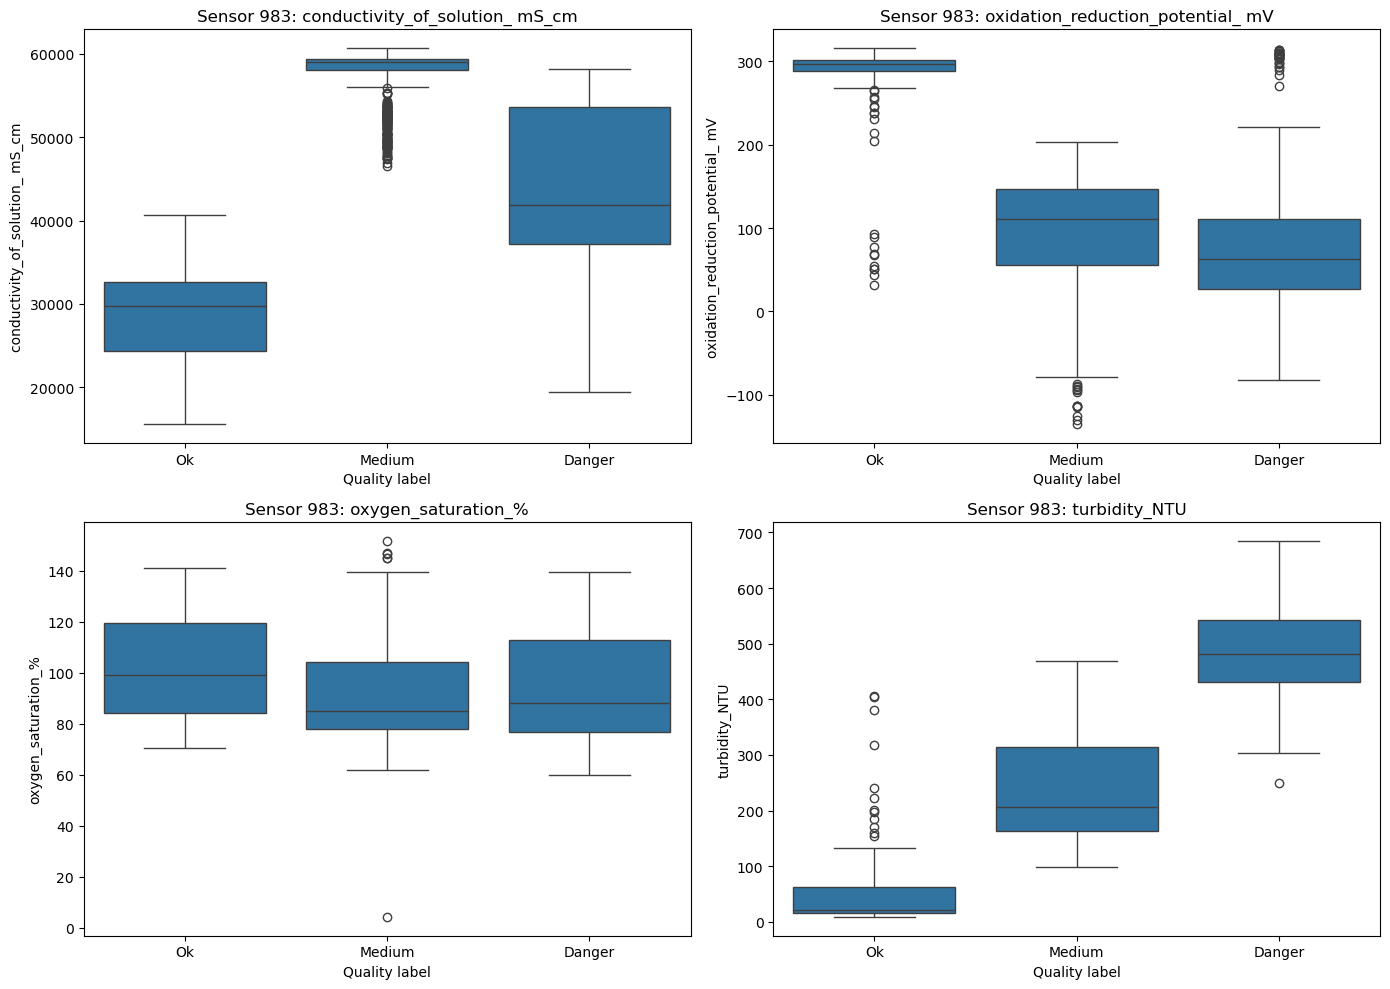

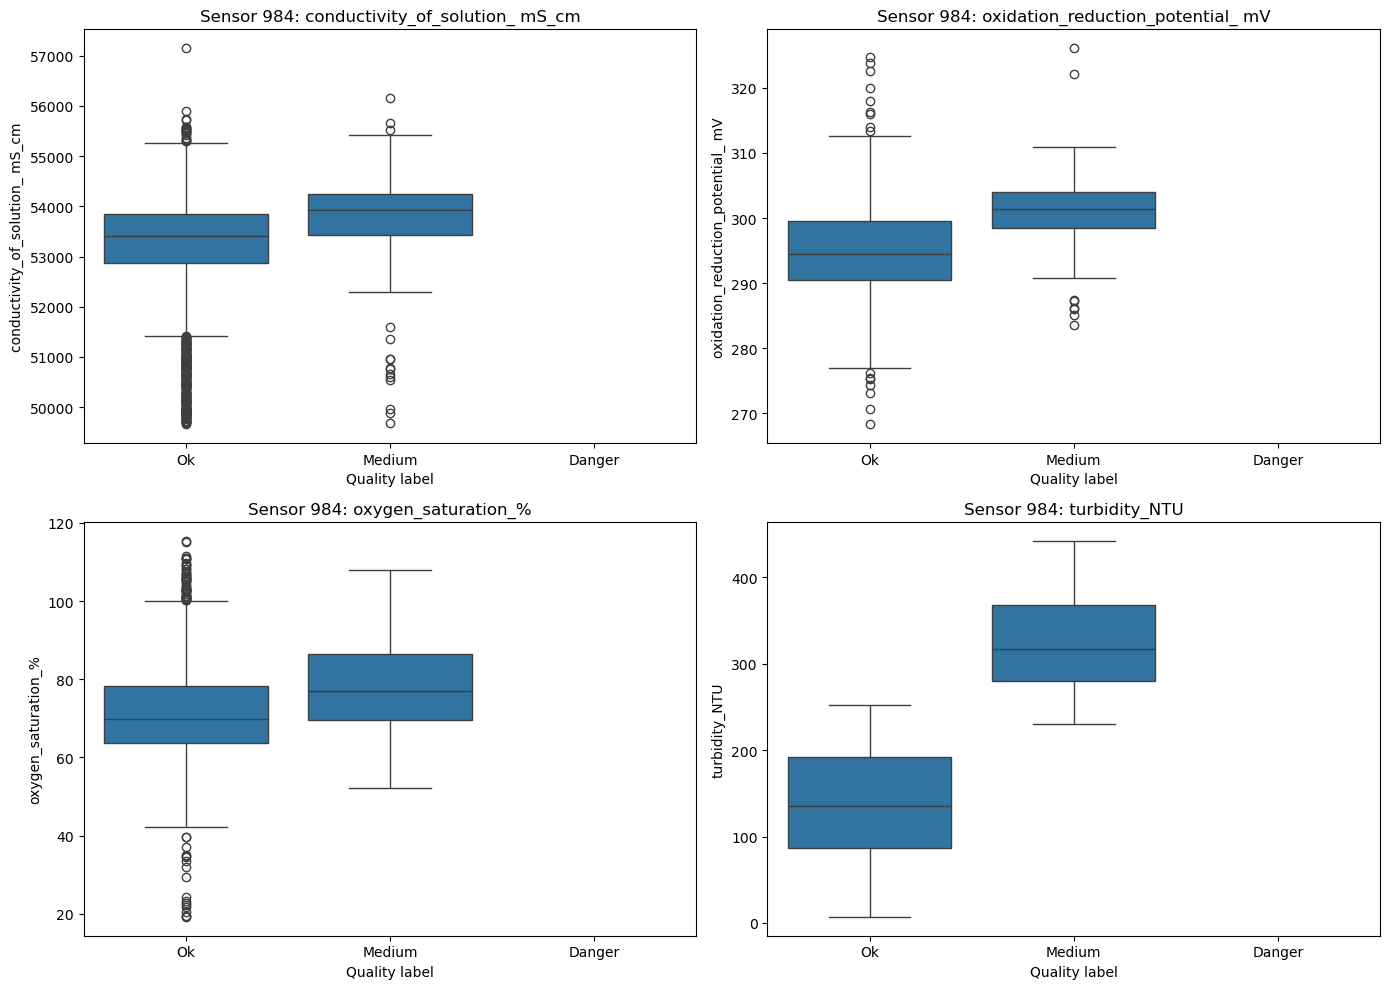

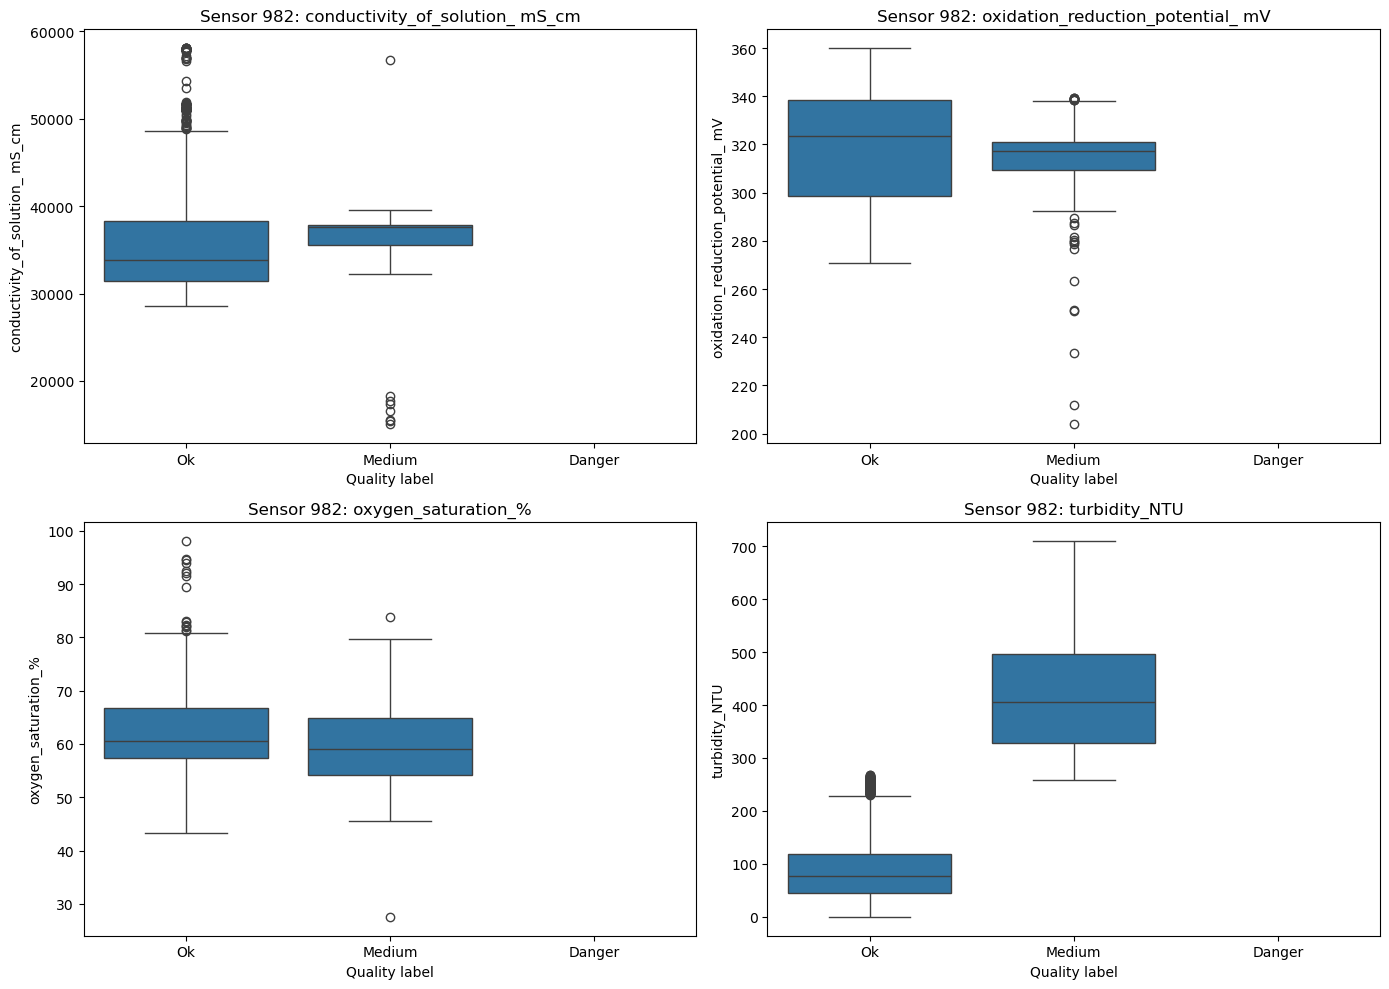

In [21]:
for sensor, sensor_data in final_training_df.groupby(
    sensor_id_col,
    sort=False
):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10)
    )

    axes = axes.flatten()

    for axis, feature in zip(axes, features):

        sns.boxplot(
            data=sensor_data,
            x="Water_Quality_Label",
            y=feature,
            order=label_order,
            ax=axis
        )

        axis.set_title(
            f"Sensor {sensor}: {feature}"
        )

        axis.set_xlabel("Quality label")

    plt.tight_layout()
    plt.show()

In [18]:
label_scaled_df["turbidity_contribution"] = (
    label_weights["turbidity"]
    * label_scaled_df["scaled_turbidity"]
)

label_scaled_df["orp_contribution"] = (
    -label_weights["orp"]
    * label_scaled_df["scaled_orp"]
)

label_scaled_df["oxygen_contribution"] = (
    -label_weights["oxygen"]
    * label_scaled_df["scaled_oxygen"]
)

label_scaled_df["conductivity_contribution"] = (
    label_weights["conductivity_deviation"]
    * label_scaled_df["conductivity_deviation"]
)

label_scaled_df[
    [
        "turbidity_contribution",
        "orp_contribution",
        "oxygen_contribution",
        "conductivity_contribution",
        "measurement_quality_score"
    ]
].head()

,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,measurement_quality_score
0,-0.798672,2.338025,-0.796232,0.307408,1.050530
1,-0.602295,2.298553,-0.901450,0.360681,1.155488
2,-1.259596,1.454690,-1.171294,0.039454,-0.936746
3,1.885114,-0.705189,-0.849136,0.736817,1.067606
4,-0.782857,0.518747,0.278415,0.153674,0.167979


In [19]:
contribution_columns = [
    "turbidity_contribution",
    "orp_contribution",
    "oxygen_contribution",
    "conductivity_contribution"
]

cluster_contributions = clustered_df[
    [sensor_id_col, "cluster", "_row_id"]
].copy()

cluster_contributions = cluster_contributions.set_index("_row_id")

cluster_contributions[contribution_columns] = (
    label_scaled_df.loc[
        cluster_contributions.index,
        contribution_columns
    ]
)

cluster_contributions = (
    cluster_contributions
    .groupby([sensor_id_col, "cluster"])[contribution_columns]
    .median()
    .reset_index()
)

cluster_contributions = cluster_contributions.merge(
    cluster_quality[
        [
            sensor_id_col,
            "cluster",
            "cluster_quality_score",
            "Water_Quality_Label"
        ]
    ],
    on=[sensor_id_col, "cluster"],
    how="left"
)

display(
    cluster_contributions.sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)

,sensor_id,cluster,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,cluster_quality_score,Water_Quality_Label
0,976,0,-1.143444,2.125349,-0.728992,0.280723,0.557539,Medium
2,976,2,-0.388723,1.894837,-0.573972,0.662525,1.760990,Medium
1,976,1,0.179526,1.976064,-0.505551,0.662525,2.496654,Danger
3,977,0,1.015124,2.346425,0.651556,0.329361,4.225923,Danger
5,977,2,2.387801,2.218777,0.082461,1.187652,5.627659,Danger
4,977,1,4.082911,2.210171,0.333093,0.267154,7.000557,Danger
6,978,0,-1.351413,1.123353,-0.656876,0.271200,-0.538549,Ok
8,978,2,1.324159,1.114297,-0.548259,0.700814,2.372286,Medium
7,978,1,2.942231,0.684105,-0.534072,0.549732,3.695038,Danger
11,979,2,-0.354982,-0.277555,0.083347,0.659629,0.095584,Medium


SENSOR 976
Observations: 1057

Label distribution:


,observations,percentage
Water_Quality_Label,,
Medium,875,82.781
Danger,182,17.219



Cluster summary:


,cluster,Water_Quality_Label,observations,cluster_quality_score,conductivity_of_solution_ mS_cm_mean,conductivity_of_solution_ mS_cm_median,oxidation_reduction_potential_ mV_mean,oxidation_reduction_potential_ mV_median,oxygen_saturation_%_mean,oxygen_saturation_%_median,turbidity_NTU_mean,turbidity_NTU_median
0,0,Medium,458,0.558,56910.009,56891.52,-134.046,-139.825,93.105,93.345,41.821,35.83
2,2,Medium,417,1.761,57089.805,57021.09,-105.925,-106.480,87.518,88.100,133.525,134.14
1,1,Danger,182,2.497,56940.232,56864.96,-108.456,-118.230,85.104,85.785,229.331,208.16



Statistics by quality label:


conductivity_of_solution_ mS_cm                       \
                                              count       mean    median   
Water_Quality_Label                                                        
Medium                                          875  56995.694  56932.05   
Danger                                          182  56940.232  56864.96   

                                                  \
                         std       min       max   
Water_Quality_Label                                
Medium               228.146  56066.99  57478.79   
Danger               304.514  55910.55  57457.55   

                    oxidation_reduction_potential_ mV                   \
                                                count     mean  median   
Water_Quality_Label                                                      
Medium                                            875 -120.645 -125.92   
Danger                                            182 -108.456 -118.23   

                             ... oxygen_saturation_%                        \
                        std  ...              median    std    min     max   
Water_Quality_Label          ...                                             
Medium               32.351  ...              90.480  5.148  71.71  103.30   
Danger               27.947  ...              85.785  5.111  68.29   97.16   

                    turbidity_NTU                                           
                            count     mean  median     std     min     max  
Water_Quality_Label                                                         
Medium                        875   85.525   80.50  50.595    8.06  181.10  
Danger                        182  229.331  208.16  59.118  178.71  569.33  

[2 rows x 24 columns]

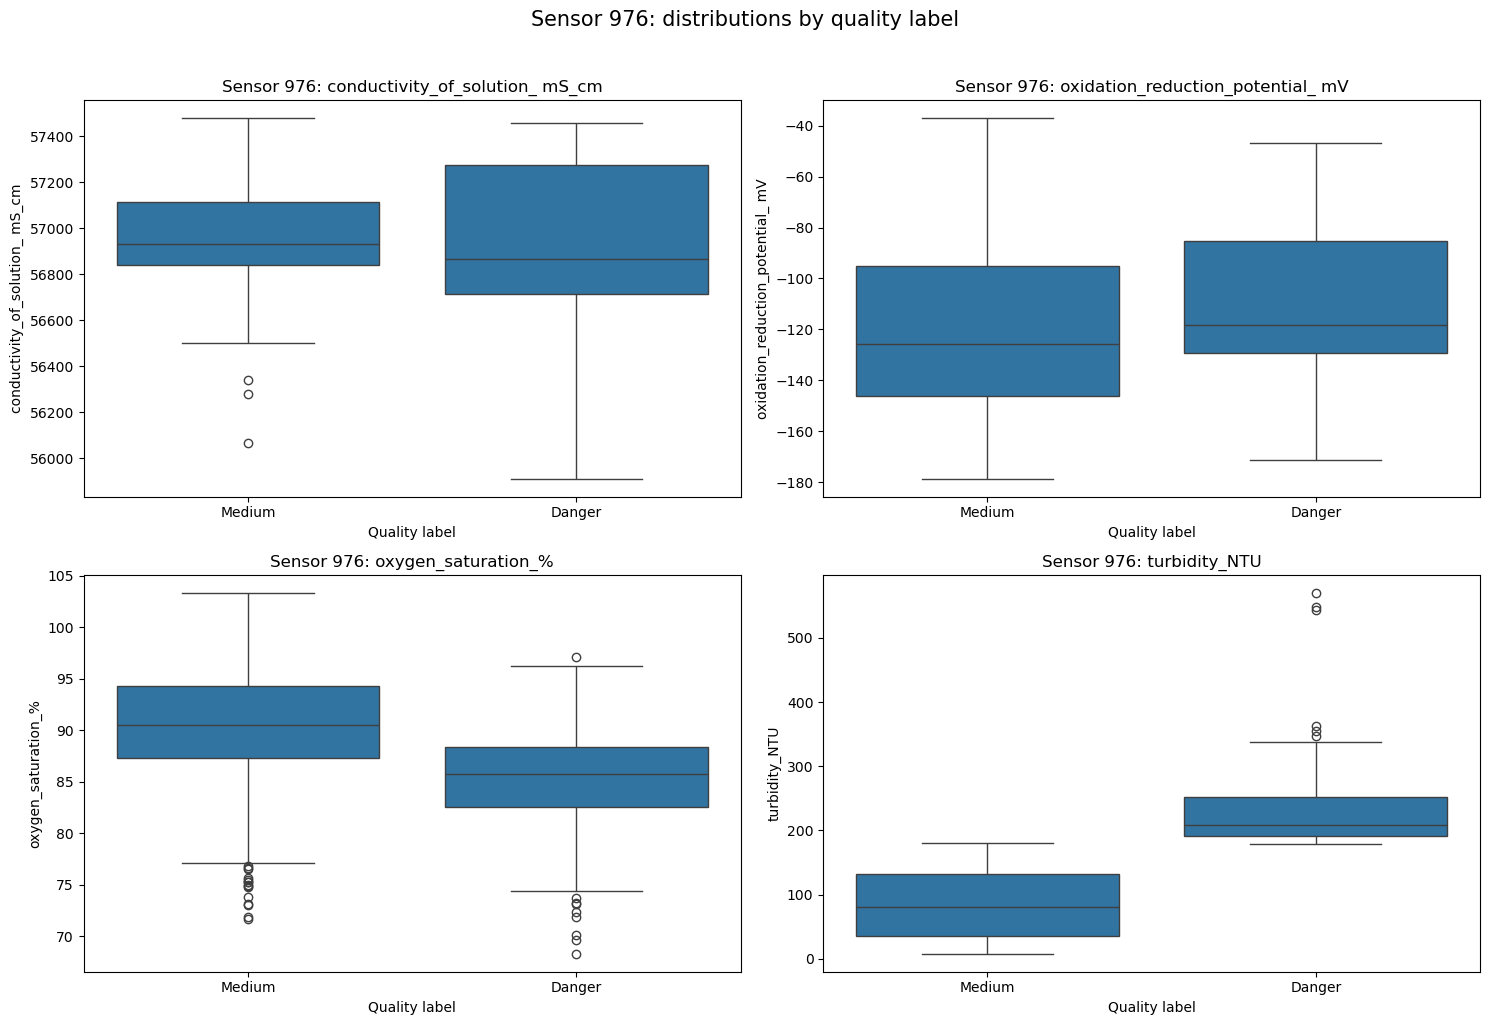

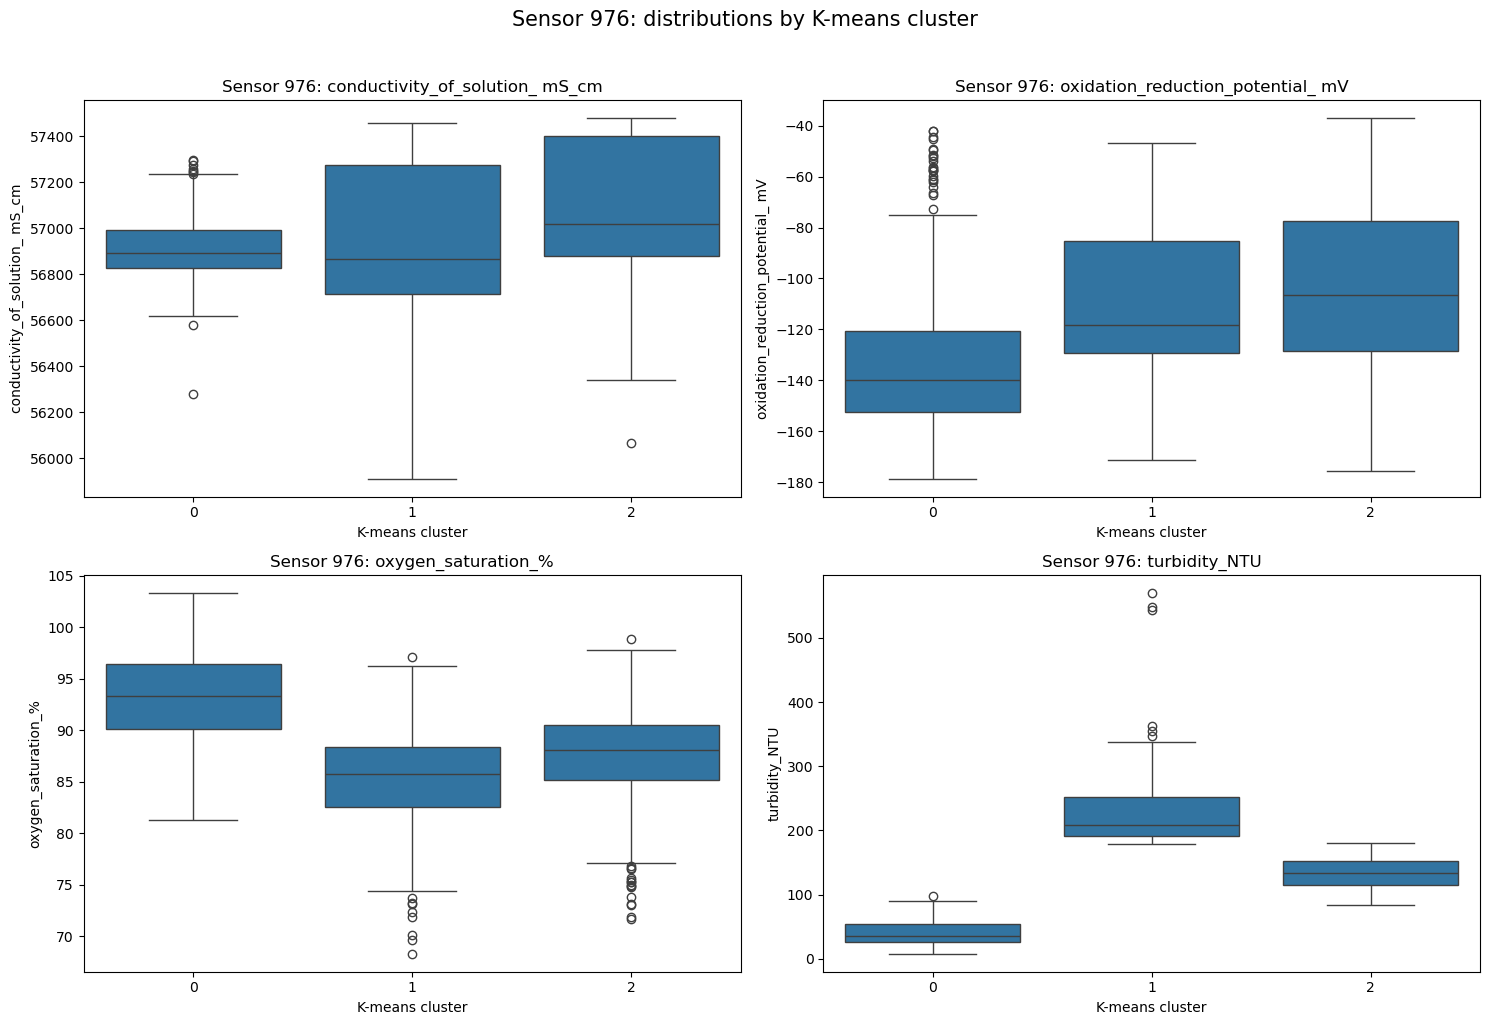

{976: {'data':       Unnamed: 0       id          date_insert  sensor_id  wtempV_°C  \
  0              2      3.0  2025-07-03 15:00:00        976      24.96   
  14            20     21.0  2025-07-03 17:00:00        976      24.70   
  22            29     30.0  2025-07-03 18:00:00        976      24.63   
  30            38     39.0  2025-07-03 19:00:00        976      24.66   
  45            56     57.0  2025-07-03 21:00:00        976      24.55   
  ...          ...      ...                  ...        ...        ...   
  7319       11276  11277.0  2025-08-28 18:00:00        976      24.82   
  7324       11285  11286.0  2025-08-28 19:00:00        976      24.65   
  7329       11294  11295.0  2025-08-28 20:00:00        976      24.54   
  7334       11303  11304.0  2025-08-28 21:00:00        976      24.42   
  7339       11312  11313.0  2025-08-28 22:00:00        976      24.26   
  
        conductivity_of_solution_ mS_cm  oxidation_reduction_potential_ mV  \
  0               

In [22]:
inspect_sensors(976,final_training_df)

In [26]:
latest_sensor_statuses = build_latest_sensor_statuses(
    final_training_df,
    cluster_contributions,
    timestamp_col="date_insert"
)

display(latest_sensor_statuses)

,sensor_id,date_insert,Water_Quality_Label,status_rank,cluster,cluster_quality_score,main_driver,explanation,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution
0,976,2025-08-28 22:00:00,Danger,2,1,2.496654,ORP,High concern is mainly associated with low ORP.,57106.35,-127.75,68.29,240.89,0.179526,1.976064,-0.505551,0.662525
1,977,2025-08-12 11:00:00,Danger,2,0,4.225923,ORP,High concern is mainly associated with low ORP.,58171.74,-89.65,44.08,159.77,1.015124,2.346425,0.651556,0.329361
2,978,2025-12-25 02:00:00,Medium,1,2,2.372286,Turbidity,Moderate concern is mainly associated with ele...,55839.19,3.92,83.27,432.50,1.324159,1.114297,-0.548259,0.700814
3,979,2025-11-27 18:00:00,Medium,1,1,2.228341,ORP,Moderate concern is mainly associated with low...,56654.33,-27.15,57.20,201.33,0.314563,1.429527,0.269992,0.177185
4,980,2025-11-14 09:00:00,Danger,2,0,2.617535,Turbidity,High concern is mainly associated with elevate...,69849.96,246.85,50.52,287.76,1.604867,-0.131588,0.567175,0.704687
5,981,2025-07-30 16:00:00,Ok,0,1,-0.670362,Turbidity,"Overall concern is low, mainly because of low ...",42890.65,354.86,39.98,8.44,-1.264049,-1.214396,0.852979,1.018804
6,982,2025-12-16 11:00:00,Ok,0,1,-1.212325,ORP,"Overall concern is low, mainly because of favo...",30080.98,325.65,69.13,54.99,-0.678029,-1.151005,0.257135,0.376594
7,983,2025-11-14 21:00:00,Medium,1,1,0.218526,ORP,Moderate concern is mainly associated with low...,55310.41,84.00,4.19,170.72,0.167857,0.395835,-0.478507,0.108598
8,984,2025-11-22 11:00:00,Ok,0,0,-1.306182,Turbidity,"Overall concern is low, mainly because of low ...",55511.24,293.33,19.39,48.65,-1.045025,-0.866053,-0.077584,0.612473


In [28]:
website_cards = latest_sensor_statuses[
    [
        "sensor_id",
        "date_insert",
        "Water_Quality_Label",
        "main_driver",
        "explanation",
        "cluster_quality_score",
        "turbidity_NTU",
        "oxidation_reduction_potential_ mV",
        "oxygen_saturation_%",
        "conductivity_of_solution_ mS_cm",
    ]
]

display(website_cards)

,sensor_id,date_insert,Water_Quality_Label,main_driver,explanation,cluster_quality_score,turbidity_NTU,oxidation_reduction_potential_ mV,oxygen_saturation_%,conductivity_of_solution_ mS_cm
0,976,2025-08-28 22:00:00,Danger,ORP,High concern is mainly associated with low ORP.,2.496654,240.89,-127.75,68.29,57106.35
1,977,2025-08-12 11:00:00,Danger,ORP,High concern is mainly associated with low ORP.,4.225923,159.77,-89.65,44.08,58171.74
2,978,2025-12-25 02:00:00,Medium,Turbidity,Moderate concern is mainly associated with ele...,2.372286,432.50,3.92,83.27,55839.19
3,979,2025-11-27 18:00:00,Medium,ORP,Moderate concern is mainly associated with low...,2.228341,201.33,-27.15,57.20,56654.33
4,980,2025-11-14 09:00:00,Danger,Turbidity,High concern is mainly associated with elevate...,2.617535,287.76,246.85,50.52,69849.96
5,981,2025-07-30 16:00:00,Ok,Turbidity,"Overall concern is low, mainly because of low ...",-0.670362,8.44,354.86,39.98,42890.65
6,982,2025-12-16 11:00:00,Ok,ORP,"Overall concern is low, mainly because of favo...",-1.212325,54.99,325.65,69.13,30080.98
7,983,2025-11-14 21:00:00,Medium,ORP,Moderate concern is mainly associated with low...,0.218526,170.72,84.00,4.19,55310.41
8,984,2025-11-22 11:00:00,Ok,Turbidity,"Overall concern is low, mainly because of low ...",-1.306182,48.65,293.33,19.39,55511.24


In [30]:
website_records = (
    website_cards
    .replace({np.nan: None})
    .to_dict(orient="records")
)

website_records

[{'sensor_id': 976,
  'date_insert': Timestamp('2025-08-28 22:00:00'),
  'Water_Quality_Label': 'Danger',
  'main_driver': 'ORP',
  'explanation': 'High concern is mainly associated with low ORP.',
  'cluster_quality_score': 2.4966543143827016,
  'turbidity_NTU': 240.89,
  'oxidation_reduction_potential_ mV': -127.75,
  'oxygen_saturation_%': 68.29,
  'conductivity_of_solution_ mS_cm': 57106.35},
 {'sensor_id': 977,
  'date_insert': Timestamp('2025-08-12 11:00:00'),
  'Water_Quality_Label': 'Danger',
  'main_driver': 'ORP',
  'explanation': 'High concern is mainly associated with low ORP.',
  'cluster_quality_score': 4.225923258577867,
  'turbidity_NTU': 159.77,
  'oxidation_reduction_potential_ mV': -89.65,
  'oxygen_saturation_%': 44.08,
  'conductivity_of_solution_ mS_cm': 58171.74},
 {'sensor_id': 978,
  'date_insert': Timestamp('2025-12-25 02:00:00'),
  'Water_Quality_Label': 'Medium',
  'main_driver': 'Turbidity',
  'explanation': 'Moderate concern is mainly associated with eleva